## Definition

> "In essence, a random variable is a real-valued function that assigns a numerical
> value to each possible outcome of the random experiment."
> — ProbabilityCourse.com

> "Given an experiment with sample space S, a random variable (r.v.) is a function
> from the sample space S to the real numbers R. [...] The randomness comes from
> the fact that we have a random experiment (with probabilities described by the
> probability function P); the mapping itself is deterministic."
> — Blitzstein, *Introduction to Probability*, Ch. 3, p. 104

## Example

Consider a single trade. The random experiment has exactly two possible outcomes:

$$S = \{\text{gain}, \text{loss}\}$$

We define a probability function $P$ on $S$ (this is our model's historical accuracy):

$$P(\text{gain}) = 0.53 \qquad P(\text{loss}) = 0.47$$

We define a random variable $X$, a deterministic function mapping each outcome to a
real number (the trade's return):

$$X(\text{gain}) = +0.01 \qquad X(\text{loss}) = -0.01$$

Note: $P$ describes the randomness; $X$ is a fixed rule, a lookup table. Nothing here
is simulated; both $P$ and $X$ are given directly.

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Sample space: the set of possible outcomes of one trade
S = ["gain", "loss"]

# Probability function P: S -> [0, 1]
P = {"gain": 0.53, "loss": 0.47}

# Random variable X: S -> R
# This is a deterministic mapping — just a dictionary, no randomness here.
X = {"gain": 0.01, "loss": -0.01}

print("Sample space S:", S)
print(f"P(gain) = {P['gain']}   P(loss) = {P['loss']}")
print(f"X(gain) = {X['gain']}   X(loss) = {X['loss']}")

Sample space S: ['gain', 'loss']
P(gain) = 0.53   P(loss) = 0.47
X(gain) = 0.01   X(loss) = -0.01


### Visualizing X as a mapping

The diagram below is a direct picture of the definition: outcomes in $S$ on the left,
real numbers in $\mathbb{R}$ on the right, and arrows showing where $X$ sends each
outcome. The randomness lives entirely in $S$ (via $P$); the arrows themselves never
change.

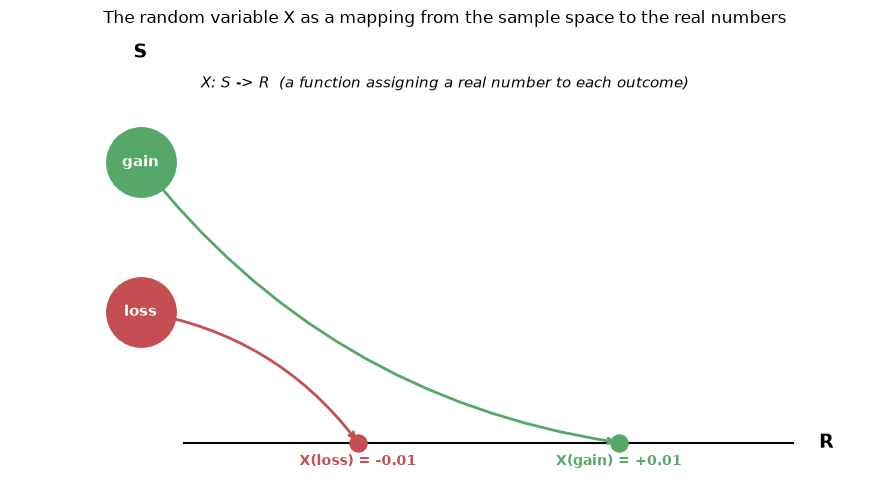

In [8]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.set_xlim(0, 10)
ax.set_ylim(-2, 10)
ax.axis("off")

# --- Sample space S (left side) ---
ax.text(1.5, 9.3, "S", fontsize=14, fontweight="bold", ha="center")
gain_pos = (1.5, 6.5)
loss_pos = (1.5, 2.5)
ax.scatter(*gain_pos, s=2500, color="#55A868", zorder=3)
ax.text(*gain_pos, "gain", ha="center", va="center", color="white", fontsize=11, fontweight="bold", zorder=4)
ax.scatter(*loss_pos, s=2500, color="#C44E52", zorder=3)
ax.text(*loss_pos, "loss", ha="center", va="center", color="white", fontsize=11, fontweight="bold", zorder=4)

# --- Real line R (bottom) ---
line_y = -1
ax.plot([2, 9], [line_y, line_y], color="black", linewidth=1.5, zorder=1)
ax.text(9.3, line_y, "R", fontsize=14, fontweight="bold", va="center")

x_gain_point = (7, line_y)
x_loss_point = (4, line_y)
ax.scatter(*x_gain_point, s=150, color="#55A868", zorder=3)
ax.scatter(*x_loss_point, s=150, color="#C44E52", zorder=3)
ax.text(x_gain_point[0], line_y - 0.6, f"X(gain) = {X['gain']:+.2f}", ha="center", color="#55A868", fontsize=10, fontweight="bold")
ax.text(x_loss_point[0], line_y - 0.6, f"X(loss) = {X['loss']:+.2f}", ha="center", color="#C44E52", fontsize=10, fontweight="bold")

# --- Arrows representing the function X ---
ax.annotate("", xy=x_gain_point, xytext=gain_pos,
            arrowprops=dict(arrowstyle="->", color="#55A868", linewidth=2, connectionstyle="arc3,rad=0.2"))
ax.annotate("", xy=x_loss_point, xytext=loss_pos,
            arrowprops=dict(arrowstyle="->", color="#C44E52", linewidth=2, connectionstyle="arc3,rad=-0.2"))

ax.text(5, 8.5, "X: S -> R  (a function assigning a real number to each outcome)",
        fontsize=11, style="italic", ha="center")

plt.title("The random variable X as a mapping from the sample space to the real numbers")
plt.tight_layout()
plt.show()

## The probability distribution table

Once we have $S$, $P$, and $X$, we can lay out the full distribution of $X$ in a
table. Each row is one outcome; the last column is the term we sum to get $E[X]$.

In [10]:
table = pd.DataFrame({
    "outcome (s)": S,
    "P(s)": [P[s] for s in S],
    "X(s)": [X[s] for s in S],
})
table["X(s) * P(s)"] = table["X(s)"] * table["P(s)"]
table

,outcome (s),P(s),X(s),X(s) * P(s)
0,gain,0.53,0.01,0.0053
1,loss,0.47,-0.01,-0.0047


## Expected value

$$E[X] = \sum_{s \in S} X(s) \cdot P(s)$$



In [11]:
EV = sum(X[s] * P[s] for s in S)
print(f"E[X] = {EV:.5f}")

E[X] = 0.00060


## Visualizing E[X] on the real line

$E[X]$ is a weighted average of the values $X$ can take, and generally it is not
one of the values $X$ actually assumes. Here, $E[X] = 0.0006$ is neither $+0.01$
nor $-0.01$; it is closer to $+0.01$ because $P(\text{gain}) > P(\text{loss})$.


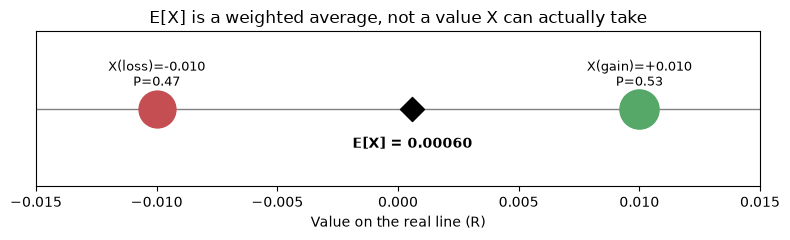

In [12]:
fig, ax = plt.subplots(figsize=(8, 2.5))

for s in S:
    color = "#55A868" if s == "gain" else "#C44E52"
    ax.scatter(X[s], 0, s=1500 * P[s], color=color, zorder=3)
    ax.text(X[s], 0.18, f"X({s})={X[s]:+.3f}\nP={P[s]:.2f}", ha="center", fontsize=9)

ax.scatter(EV, 0, marker="D", s=150, color="black", zorder=4)
ax.text(EV, -0.3, f"E[X] = {EV:.5f}", ha="center", fontsize=10, fontweight="bold")

ax.axhline(0, color="gray", linewidth=1)
ax.set_ylim(-0.6, 0.6)
ax.set_xlim(min(X.values()) - 0.005, max(X.values()) + 0.005)
ax.set_yticks([])
ax.set_xlabel("Value on the real line (R)")
ax.set_title("E[X] is a weighted average, not a value X can actually take")
plt.tight_layout()
plt.show()

## Why this connects back to EV in trading

In the walk-forward notebook, `trade_return = signal * return` is exactly a random
variable: for each period $t$, it maps the (unknown, random) outcome of the market
to a real number. `ev = trade_returns.mean()` is the *sample* mean, an estimate of
$E[X]$ built from observed data rather than the exact formula above (which requires
knowing $P$ in advance). Both compute the same quantity; one is a formula, the other
an empirical estimate of it.

## A second random variable, for comparison

Let's define a second random variable $Y$ on the *same* sample space $S$, but with a
different, asymmetric mapping: a larger loss than gain and a higher win probability.
No simulation here either; just a different lookup table.

In [13]:
P_Y = {"gain": 0.65, "loss": 0.35}
Y = {"gain": 0.005, "loss": -0.02}

EV_Y = sum(Y[s] * P_Y[s] for s in S)

print(f"X: P(gain)={P['gain']:.2f}  E[X] = {EV:.5f}")
print(f"Y: P(gain)={P_Y['gain']:.2f}  E[Y] = {EV_Y:.5f}")

X: P(gain)=0.53  E[X] = 0.00060
Y: P(gain)=0.65  E[Y] = -0.00375


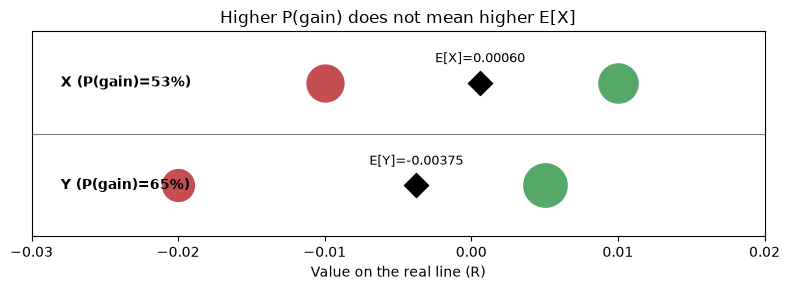

In [14]:
fig, ax = plt.subplots(figsize=(8, 3))

for label, Pd, Xd, y_offset in [("X", P, X, 0.3), ("Y", P_Y, Y, -0.3)]:
    ev = sum(Xd[s] * Pd[s] for s in S)
    for s in S:
        color = "#55A868" if s == "gain" else "#C44E52"
        ax.scatter(Xd[s], y_offset, s=1500 * Pd[s], color=color, zorder=3)
    ax.scatter(ev, y_offset, marker="D", s=150, color="black", zorder=4)
    ax.text(-0.028, y_offset, f"{label} (P(gain)={Pd['gain']:.0%})", va="center", fontsize=10, fontweight="bold")
    ax.text(ev, y_offset + 0.12, f"E[{label}]={ev:.5f}", ha="center", fontsize=9)

ax.axhline(0, color="gray", linewidth=0.8)
ax.set_xlim(-0.03, 0.02)
ax.set_ylim(-0.6, 0.6)
ax.set_yticks([])
ax.set_xlabel("Value on the real line (R)")
ax.set_title("Higher P(gain) does not mean higher E[X]")
plt.tight_layout()
plt.show()